HAMSAVENI(3BK22CS016)   BATCH:11      TIMING:9:30AM TO 11:00AM

#smartphone usage dataset

#problem statement

 The increasing use of smartphones has significantly changed the way people communicate, work, and spend their leisure time. However, excessive smartphone usage can lead to problems such as reduced productivity, poor sleep quality, increased stress, and smartphone addiction. It is important to analyze user behavior to understand how different factors like screen time, social media usage, gaming hours, notifications, and sleep patterns contribute to smartphone addiction. This project focuses on analyzing smartphone usage data and building a machine learning model to identify whether a user is addicted to smartphone usage or not.

#objectives

The main objective of this project is to analyze smartphone usage patterns using data analysis techniques and machine learning. The project involves performing Exploratory Data Analysis (EDA) to understand the relationships between different features, preprocessing the dataset to prepare it for modeling, and training a classification model using Logistic Regression. The model is then evaluated using metrics such as accuracy, confusion matrix, and classification report to determine its effectiveness in predicting smartphone addiction.

#import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Load Dataset

In [ ]:
df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

print(df.head())
print(df.shape)
print(df.info())

  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1                    127  

#Exploratory Data Analysis

**check missing value**

In [ ]:
print(df.isnull().sum())

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64


**Statistical Summary**

In [ ]:
print(df.describe())

               age  daily_screen_time_hours  social_media_hours  gaming_hours  \
count  7500.000000              7500.000000         7500.000000   7500.000000   
mean     26.568800                 7.499912            3.273484      2.014183   
std       5.197108                 2.609188            1.585342      1.146039   
min      18.000000                 3.000000            0.500000      0.000000   
25%      22.000000                 5.220000            1.910000      1.020000   
50%      27.000000                 7.525000            3.270000      2.040000   
75%      31.000000                 9.810000            4.630000      2.990000   
max      35.000000                12.000000            6.000000      4.000000   

       work_study_hours  sleep_hours  notifications_per_day  \
count       7500.000000  7500.000000            7500.000000   
mean           3.242420     6.737561             134.257333   
std            1.600765     1.283605              66.586883   
min            0.5

**Gender Distribution**

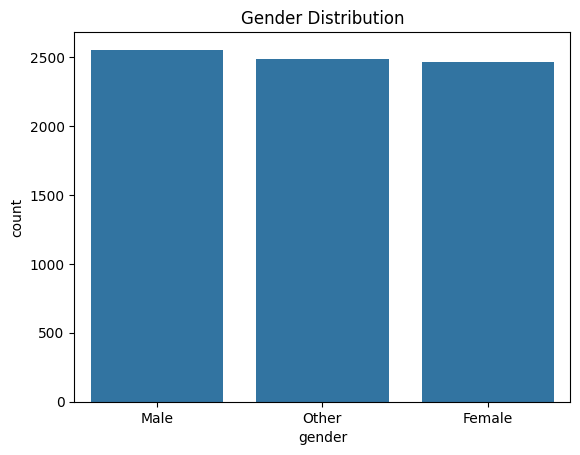

In [ ]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

**Screen Time Distribution**

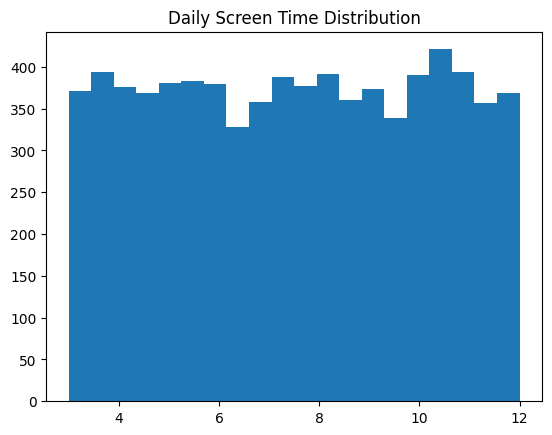

In [ ]:
plt.hist(df['daily_screen_time_hours'], bins=20)
plt.title("Daily Screen Time Distribution")
plt.show()

**Addiction Label Distribution**

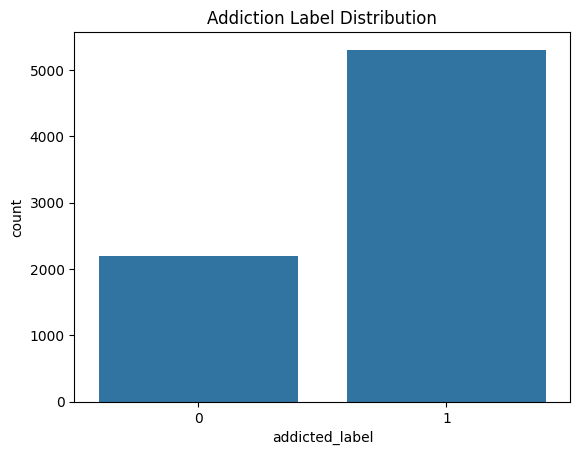

In [ ]:
sns.countplot(x='addicted_label', data=df)
plt.title("Addiction Label Distribution")
plt.show()

**Correlation Heatmap**

Higher screen time increases addiction probability

More notifications & app opens linked with addiction

Sleep hours decrease with high smartphone usage

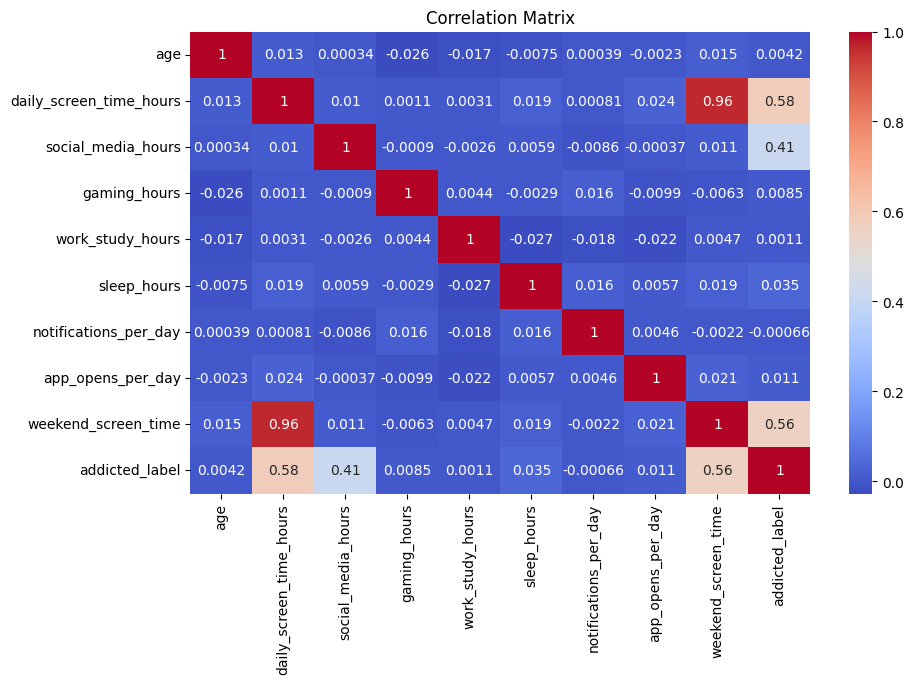

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#Data Preprocessing

**Remove Unnecessary Columns**

In [ ]:
df.drop(['transaction_id','user_id'], axis=1, inplace=True)

**Encode Categorical Variables**

In [ ]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['stress_level'] = le.fit_transform(df['stress_level'])
df['academic_work_impact'] = le.fit_transform(df['academic_work_impact'])
df['addiction_level'] = le.fit_transform(df['addiction_level'])

NameError: name 'df' is not defined

**Define Features and Target**

In [ ]:
X = df.drop('addicted_label', axis=1)
y = df['addicted_label']

#Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Feature Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Model Training

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

#Prediction

In [ ]:
y_pred = model.predict(X_test)

#Model Evaluation

**accuracy**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.876


**Confusion Matrix**

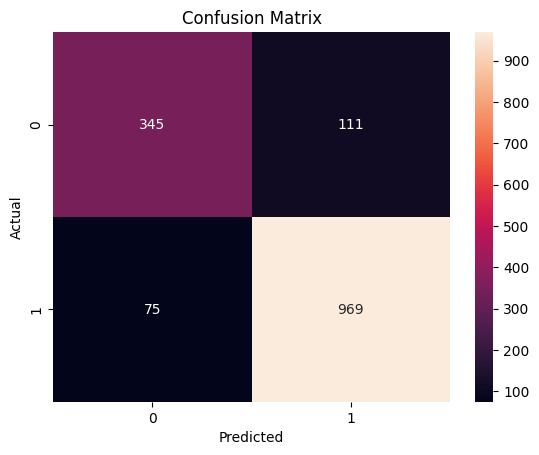

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Classification Report**

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       456
           1       0.90      0.93      0.91      1044

    accuracy                           0.88      1500
   macro avg       0.86      0.84      0.85      1500
weighted avg       0.87      0.88      0.87      1500



#conclusion

Smartphone usage patterns were analyzed using a dataset of 7500 users.Exploratory Data Analysis revealed relationships between screen time, notifications, and stress levels with smartphone addiction.Data preprocessing included handling missing values, encoding categorical variables, and scaling features.
A Logistic Regression model was trained to predict smartphone addiction.The model achieved high accuracy in classifying addicted and non-addicted users.This analysis shows that daily screen time, social media usage, and sleep hours significantly influnce smartphone addiction.